<a href="https://colab.research.google.com/github/elean23/2025-webinar-ml-with-python/blob/main/M7_C3_abiertaUGR_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

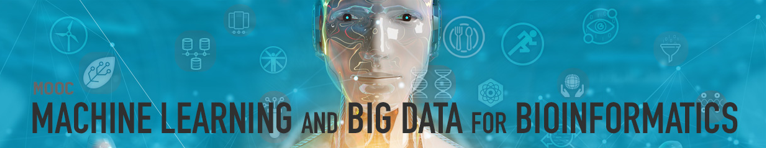
## **Module 7 Big data**
### **7.3 Machine learning in *Spark*:*MLlib***

**By Francisco Javier García Castellano**

*Associate Professor at the Department of Computer Science and Artificial Intelligence (DECSAI), University of Granada.*

**Reminder: Introduction to this NoteBook**.

In this NoteBook, you will be guided step-by-step,through loading a dataset to the descriptive analysis of its contents.

The *Jupyter NoteBook* (Python) is an approach that combines text blocks (like this one) and code blocks or cells. The great advantage of this system is its interactivity because cells can be executed to directly check the results they contain. *Very important*: the order of the instructions is fundamental and so each cell of this NoteBook must be executed sequentially. In any are omitted, the program may throw an error and so if there is any doubt, you will have to start from the beginning again.

First, it is very important to select "*Open in draft mode*" (draft mode) at the top left at the beginning. Otherwise, for security reasons, it will not be allowed to execute any code blocks. When the first of the blocks is executed, the following message will appear: "*Warning: This NoteBook was not created by Google*". Don't worry, you can trust the contents of the *NoteBook* and click on "Run anyway".

Let's start!

Click on the "play" button on the left side of each code cell. Remember that lines beginning with a hashtag (#) are comments and do not affect the execution of the script.

You can also click on each cell and press "*Ctrl+enter*" (*Cmd+enter* on Mac).

Each time you execute a block, you will see the output just below it. The information is usually always the last statement, along with any `print()` commands present in the code.


## **INDEX**


In this NoteBook:
1. We will start to understand the machine learning part of Apache *Spark*: *MLlib*.
2. We see how to prepare the data so that a model can learn it.
3. We learn how to use the pipeline to optimize the workflow.
4. We will discover how to validate the learned models in Spark.

Contents:
1. Introduction.

2. Preparing DataFrames for *Spark MLlib*.
  
3. *Spark* pipelines.

4. Machine learning pipelines.

5. Evaluation metrics for supervised learning models.

6. Supervised learning model validation.


##**1. INTRODUCTION**

*MLlib* is the machine learning library for Apache *Spark*. The interesting thing about *MLlib* is that, because it is designed for *Spark*, its algorithms are intended for distributed environments, are highly scalable, and are fault-tolerant.

*MLlib* provides the following tools:

* Machine learning algorithms: Standard classification, regression, clustering, and collaborative filtering algorithms.
* Featurization: Feature extraction, transformation, dimensionality reduction, and selection.
* Pipelines: A tool for optimizing machine learning workflows.
* Persistence: A feature for saving and reading algorithms, models, and pipelines.
* Utilities: Linear algebra, statistics, and data management tools, etc.

When using Python, two programming interfaces can be found in *MLlib*:
* [Spark ML](https://spark.apache.org/docs/latest/api/python/pyspark.ml.html ), or the [DataFrame MLlib API](https://spark.apache.org/docs/latest/mllib-guide.html#mllib-main-guide)(application programming interface): This is based on DataFrames and is contained in the `spark.ml` package. *Spark ML* has been the default interface since version 2.0 and so we advise you to use this one.
* [Spark MLlib](https://spark.apache.org/docs/latest/api/python/pyspark.mllib.html ), or the [RDD MLlib API](https://spark.apache.org/docs/latest/mllib-guide.html#mllib-rdd-based-api-guide): This is the original programming interface and is based on RDD. This interface is found inside the `spark.mllib` package, but is currently available in maintenance mode only.

The RDD-based API was changed to a DataFrame-based interface because, as we have already seen, the latter is faster and easier to handle.

In this NoteBook we will continue working with *Spark* in Google Colaboratory, and so the prolegomena are the same, as shown below.

In [ ]:
#First, we install Java and Apache Spark with Hadoop.
#!apt-get install openjdk-8-jdk-headless -qq
!wget -q --show-progress   https://downloads.apache.org/spark/spark-4.1.1/spark-4.1.1-bin-hadoop3.tgz
!tar xf spark-4.1.1-bin-hadoop3.tgz

#Install the Python packages to work with Spark.
!pip install findspark #Install FindSpark
!pip install pyspark   #Install PySpark

#Specify the location of Spark so that PySpark can use it.
import findspark
findspark.init("spark-4.1.1-bin-hadoop3")#SPARK_HOME

#Set the environment variables.
import os
#os.environ["JAVA_HOME"] = "/usr/lib/jvm/default-java"
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-4.1.1-bin-hadoop3"


#Create a Spark session to start working.
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Example PySpark Machine Learning") \
    .config("spark.sql.execution.arrow.enabled", "true") \
    .getOrCreate()



spark-4.1.1-bin-had 100%[===================>] 546.21M  24.4MB/s    in 22s     


As we saw in Capsule 1 of Module 3 (*Data science and machine learning: what, why, and how?*), a data science project typically involves preprocessing data, selecting input variables, learning a model, and evaluating the results. We refer to this as the **data science life cycle**.
In this capsule we will see how to carry out this life cycle using Apache *Spark*.

##**2. PREPARING THE DATAFRAMES FOR *SPARK MLLIB***



To work with *Spark* machine learning algorithms, we will must first prepare the data so that it can be processed. Moreover, *Spark ML* machine learning algorithms only work  with data in a numerical format and so, any categorical variables must be first converted to a numerical format .

Let's see some of the methods used to transform variables:

* [`StringIndexer`](http://spark.apache.org/docs/latest/ml-features.html#stringindexer): Assigns an integer to each possible category. The value zero is assigned to the most frequent category, 1 to the next one, and so on. We must indicate the column we want to index and the name of the output column. The scheme used is saved in the metadata in case we want to undo this step by employing the [`IndexToString()`](http://spark.apache.org/docs/latest/ml-features.html#indextostring) method.



* [`Vector Assembler`](http://spark.apache.org/docs/latest/ml-features.html#vectorassembler): This allows us to combine a given list of columns into a single column vector. This is because machine learning algorithms accept a DataFrame in which the input variables are in a single column and, in the case of supervised learning, there will also be a second column with the output variable.

  This step usually occurs at the end of the data preprocessing, when we are going to pass the training data to the machine learning method.


To illustrate the different examples, we will work with the same skin melanoma supervised learning problem we have been using throughout this course. First, we will download the data inorder to work with it. Subsequently, we will index the output variable. Then, we will join the input variables in a list in a new column, using `vectorAssembler'. Finally, we show only these two generated columns, one with the output variable in numerical format and one with the input variables grouped.


In [ ]:
#Download the data files in Google Colaboratory.
!wget -nv --no-check-certificate 'https://docs.google.com/uc?export=download&id=1T88IS0cg1VRsNelrrE7Q6esfQC8lA3Ht' -O inmune_X.csv
!wget -nv --no-check-certificate 'https://docs.google.com/uc?export=download&id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s' -O inmune_Y.csv

#Display the header of the files and two rows, in order to check that
#they have been downloaded correctly.
!head -3 inmune_X.csv
!head -3 inmune_Y.csv

#Read the file with the input variables.
dfX = spark.read.csv('inmune_X.csv',inferSchema=True, header=True)
#Read the file with the output variable.
dfY = spark.read.csv('inmune_Y.csv',inferSchema=True, header=True)

#Join the two DataFrames.
df=dfX.join(dfY, dfX._c0 == dfY._c0).drop('_c0')

#Drop the column that indicates the instance number.
dfX=dfX.drop('_c0')
dfY=dfY.drop('_c0')

#Preprocess the data that will be used in a machine learning algorithm.
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler

#Index the output variable.
indexer = StringIndexer(inputCol="RNASEQ-CLUSTER_CONSENHIER", outputCol="class")
indexed= indexer.fit(df).transform(df)
indexed.show(5)

#Join the input variables with VectorAssembler.
assembler = VectorAssembler(inputCols=dfX.columns,outputCol="features")
data = assembler.transform(indexed)
data.select('features','class').show(5)


2026-03-09 09:19:14 URL:https://drive.usercontent.google.com/download?id=1T88IS0cg1VRsNelrrE7Q6esfQC8lA3Ht&export=download [9152821/9152821] -> "inmune_X.csv" [1]
2026-03-09 09:19:15 URL:https://drive.usercontent.google.com/download?id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s&export=download [3949/3949] -> "inmune_Y.csv" [1]
,TYRP1,RPS4Y1,KRT6A,XIST,KRT14,KRT16,KRT5,XAGE1B,KRT6B,PAEP,KRT6C,MAGEC2,DDX3Y,KRT1,KDM5D,MAGEA4,KRT17,MAGEC1,OCA2,NELL1,PMEL,PAGE5,CTAG2,MAGEA6,MAGEA2B,EDN3,S100A7,MAGEA3,HHATL,MAGEA12,CTAG1A,SPRR1B,TRPM1,EIF1AY,CALML3,SFN,VGF,DCT,ABCB5,EYA1,IL13RA2,MAGEA1,GAGE12J,CSAG1,USP9Y,CALML5,LRP2,FDCSP,SFRP1,TRIM29,MLANA,UTY,GJB6,CCL21,MAPK4,CHST9,TF,COL11A1,PRKG2,SBSN,KRTDAP,SOSTDC1,CNDP1,COL9A1,COL22A1,FABP7,PKP1,FAM178B,MAGEA10,PI3,ABCA8,ALDH3B2,MAGEB2,CDH1,CR2,RP11_986E7_7,ADAM6,IVL,LGALS7,DSC3,SCRG1,DSG1,ITIH6,PMP2,SPRR1A,BAAT,COMP,SPRR2A,SPRR2E,GPR143,GSTT1,DSG3,COL2A1,TYR,ZFY,TXLNG2P,ADCY2,BMP7,ANGPTL7,GATA4,BCAN,KLK6,CMTM5,LOXL4,CSMD1,PCSK2,LY6D,MEGF10,IGJ,HOXB13,PRDM7,LR

##**3. *SPARK* PIPELINES**

Data science projects typically involve preprocessing the data, selecting input variables, learning a model, and evaluating the results. Therefore, we must perform a series of data transformations in sequence. [Pipelines](https://spark.apache.org/docs/latest/ml-pipeline.html
 ) make it more convenient to combine different algorithms in a single workflow. To work with pipelines, we must first be aware of some previous concepts:

* DataFrame: The data structure used in our examples (which we should already know).

* [Transformers](http://spark.apache.org/docs/latest/ml-features.html): A Transformer is an algorithm that can transform one DataFrame into another DataFrame. For example, in the previous section, we saw several transformations for categorical variables. Another example would be a Machine Learning model that transforms a DataFrame with only input variables into predictions of the output variable. A Transformer is an abstraction that includes transformations of the learned variables or models. Technically, a Transformer implements the `transform()` method, which converts one DataFrame into another, usually by adding one or more columns.

* Estimator: An Estimator is an algorithm that can be fitted to (or learned from) a DataFrame to produce a Transformer. For example, a learning algorithm is an Estimator trained on a DataFrame (using the `fit()` method)  which then returns a model.

* Pipelines: A pipeline chains multiple Transformers and Estimators to specify a machine learning workflow. For example, we could add indexing and assembly of input variables in a pipeline and then learn a logistic regression.

* Parameters: All Transformers and Estimators share a common interface for specifying parameters.


A pipeline is a sequence of stages, where each one is either a Transformer or an Estimator. These stages are executed in order, and the input DataFrame is transformed at each stage. For Transformer stages, the `transform()` method is called up on the DataFrame. For Estimator stages, the `fit()` method is used to produce a Transformer, and that Transformer’s `transform()` method is called on the DataFrame.

Following the example given above, we could have performed all these transformations using a pipeline as follows:


In [ ]:
#Index the input variable.
indexer = StringIndexer(inputCol="RNASEQ-CLUSTER_CONSENHIER", outputCol="class")

#Join the input variable using VectorAssembler.
assembler = VectorAssembler(inputCols=dfX.columns,outputCol="features")

#Add the preprocessing to a pipeline.
from pyspark.ml import Pipeline
stages=[indexer, assembler]
partialPipeline = Pipeline().setStages(stages)

#Build the model.
myPipeline = partialPipeline.fit(df)

#Transform the data and show them.
preprocessedData = myPipeline.transform(df)
preprocessedData.select('features','class').show(5)

+--------------------+-----+
|            features|class|
+--------------------+-----+
|[2.75046277351166...|  1.0|
|[-5.5660300159965...|  0.0|
|[-4.9072628904726...|  0.0|
|[5.54681507588922...|  1.0|
|[7.03679481902784...|  1.0|
+--------------------+-----+
only showing top 5 rows


Thus, pipelines optimize the data preprocessing, which is very important when dealing with huge data volumes.

The figure below shows the *Spark* pipeline scheme we followed in the data preprocessing example.

![imagen.png](data:image/png;base64,)
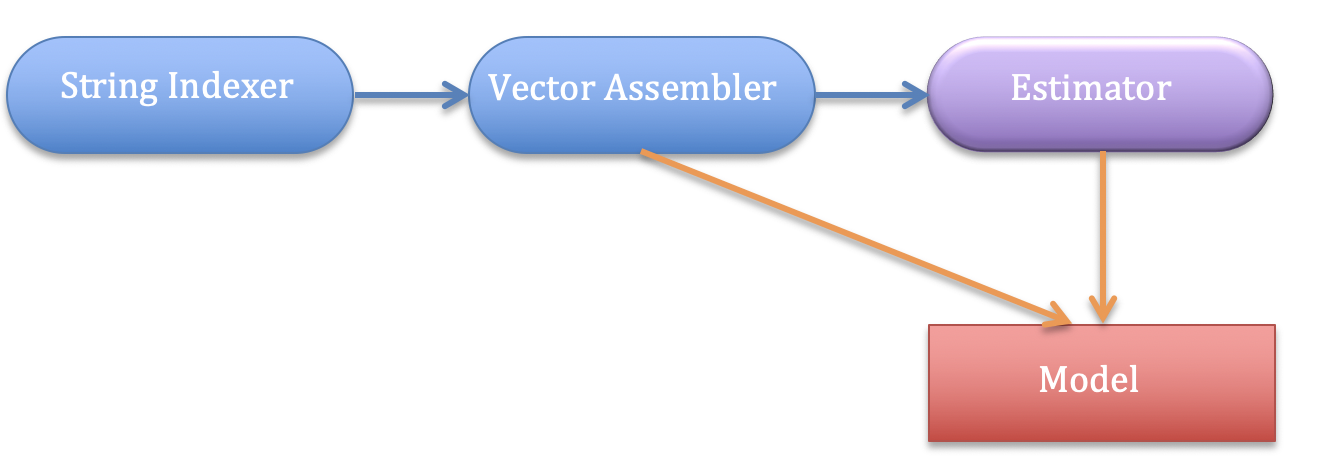


> *Figure 1. Example of a pipeline diagram in Apache Spark.*

Once the data is preprocessed, we can split it into two sets (one for training and the other for testing) in order to start a machine learning algorithm.


In [ ]:
train, test = preprocessedData.select('features','class').randomSplit([0.7, 0.3], seed = 2020)
print("Train DataFrame : " + str(train.count())+" instances.")
print("Test  DataFrame : " + str(test.count())+" instances.")

Train DataFrame : 254 instances.
Test  DataFrame : 82 instances.


As we saw in Capsule 2 of Module 3 (*Supervised learning*), the use of cross-validation rather than training and testing is preferable. However, when dealing with big data, we cannot always handle the computational cost of cross-validation. This means that we will have to use two disjointed sets for training and testing. Nevertheless, although this much less expensive in terms of processing, it is less statistically rigorous.

##**4. LEARNING PIPELINES**

As we have seen, we have included all the preprocessing of our dataset in a pipeline. Now we will see how to also add a machine learning algorithm to this.

We will follow a supervised learning example and we will learn a logistic regression classifier based on the data generated earlier.

Following *Spark* terminology, we will learn a Transformer model (which uses the `transform()` method) using a logistic regression Estimator (which uses the `fit()` method). That is, we will learn an Estimator with the training data and, then this model will be used as a Transformer on the test data to convert it into a series of predictions. In turn, these predictions will be used to calculate the accuracy of the model.



In [ ]:
from pyspark.ml.classification import LogisticRegression
#Learn a logistic regression model.
lr = LogisticRegression(featuresCol = 'features', labelCol = 'class', maxIter=10)
lrModel = lr.fit(train)

#Obtain the test set predictions.
predictions = lrModel.transform(test)

#Compute the accuracy of the model.
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(labelCol="class", metricName="accuracy")
print('Accuracy:', evaluator.evaluate(predictions))

Accuracy: 0.7926829268292683


We can improve the previous example by adding the logistic regression model to the pipeline, allowing *Spark* to optimize the process further. First, we will split the data into training and test sets and then we will define the pipeline and learn the model. This model, along with the data preprocessing and the classifier, will then be applied to the test set to make the predictions abput the data and calculate the proportion of outcomes it accurately classifies.  

In [ ]:
#Split the data (without preprocessing).
train, test = df.randomSplit([0.7, 0.3], seed = 2020)

#Index the output variable.
indexer = StringIndexer(inputCol="RNASEQ-CLUSTER_CONSENHIER", outputCol="class")

#Join the input variables with VectorAssembler.
assembler = VectorAssembler(inputCols=dfX.columns,outputCol="features")

#Add the logistic regression model.
lr = LogisticRegression(featuresCol = 'features', labelCol = 'class', maxIter=10)

#Add the stages to the pipeline.
stages=[indexer, assembler,lr]
model = Pipeline().setStages(stages)

#Build the model: preprocessing + logistic regression.
classfier = model.fit(train)

#Obtain the predictions on the test set.
predictions = classfier.transform(test)

#Display the accuracy of the model.
evaluator = MulticlassClassificationEvaluator(labelCol="class", metricName="accuracy")
print('Accuracy:', evaluator.evaluate(predictions))


Accuracy: 0.7926829268292683


Let's now look at the metrics and validation models that we can use in *Spark*, especially focusing on supervised learning. It will be in the next capsule we will talk about how to use *Spark* for unsupervised learning.

##**5. EVALUATION METRICS FOR SUPERVISED LEARNING MODELS**




Supervised learning tools can be divided into classifiers and regressors depending on whether the variable we want to predict is discrete or continuous.

From among the classifiers, we can distinguish those that are used for binary classification (i.e., where the output variable has only two states) from those used for multiclass classification (i.e., in which the output variable has more than two states).

Note that classifiers that allow us to work with multiclass problems also allow us to work with binary problems. This makes sense becasue if an algorithm can discriminate between 4 or 10 values of the output variable, it should also be able to distinguish between 2.

However, we can also use binary classifiers in multiclass problems, for example, by using the One-vs-All methodology.  This scheme constructs a base classifier for each value of the output variable, which then distinguishes the i-th value from the rest.

We have already seen different metrics for evaluating supervised learning algorithms in previous modules in this course. Let’s now see how to obtain them with *Spark*.

First, we will focus on the case of binary classification problems by applying the `BinaryClassificationEvaluator` class. This allows us to
calculate the `areaUnderROC` measure, in other words, the area under the ROC curve or AUC, as seen in previous modules.
<!--calcular dos medidas:


1.   `areaUnderROC` : El área bajo la curva ROC, o también ROC AUC. Se ha visto ya previamente.
2.   `areaUnderPR`: Es el área bajo la curva  Precision-Recall, o también Precision-Recall AUC. La curva PR es el resultado de dibujar la gráfica entre el precision y el recall. Esta gráfica nos permite ver a partir de qué recall tenemos una degradación de la precisión y viceversa. Lo ideal sería una curva que se acerque lo máximo posible a la esquina superior derecha (alta precisión y alto recall). Esta métrica es más apropiada para conjuntos no balanceados, es decir, hay un reparto desigual acusado entre las dos clases del problema.

Vamos a usar el ejemplo anterior para mostrar ambas métricas:

-->
<!-- #La regresión logística, también nos permite mostras la curvas ROC
import matplotlib.pyplot as plt
trainingSummary = clasificador.stages[-1].summary
roc = trainingSummary.roc.toPandas()
plt.plot(roc['FPR'].tolist(),roc['TPR'].tolist(),color='orange')
plt.ylabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1], color='navy',  linestyle='--')
plt.show()
-->

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

#We can now display the goodness of model predictions.
evaluator = BinaryClassificationEvaluator(labelCol="class", metricName="areaUnderROC")
print('ROC AUC:', evaluator.evaluate(predictions))

ROC AUC: 0.8938580799045913



We will now study multiclass classification. Of note, the measures used can also be computed in binary classification. In this case, we will use the `MulticlassClassificationEvaluator` class to obtain the following measures:

* `accuracy`: Tthe ratio of  well-classified instances. This refers to the ratio of correctly identified instances compared to the total number of instances.
* `weightedPrecision`: This is the average *precision* (i.e., the mean *precision* per tag is calculated).
* `weightedRecall`: This is the average *recall* per tag.
* `f1`: Also called the *F-measure*, this metric combines *precision* and *recall*.

Let's continue with the previous example given that, even if it is a binary classification problem, we can still calculate these metrics:


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

#Show the goodness of multiclass model predictions.
evaluator = MulticlassClassificationEvaluator(labelCol="class")
print('F1:', evaluator.evaluate(predictions))
print('Accuracy:', evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"}))
print('Weighted Precision:', evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"}))
print('Weighted Recall:', evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"}))

F1: 0.7902653265514936
Accuracy: 0.7926829268292683
Weighted Precision: 0.7998323170731707
Weighted Recall: 0.7926829268292683


When we are trying to predict a continuous variable, the machine learning model is known as a regressor. For regression, we will use the `RegressionEvaluator` class and the metrics seen in Module 4 (*Supervised learning: regression techniques*) that we can obtain are:
* `rmse`: This is the square root of the mean square error (root mean square error). The square root is used so that the scale of the errors equals to the scale of the targets.

* `r2`: The coefficient of determination, or $r^2$, is closely related to the mean squared error, but will always fall between -∞ and 1.

We will continue with the previous example, but bear in mind that because is a binary classification problem, its results will not make much sense. We are following this example through to see how it is used:



In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

#Display the goodness of the model predictions.
evaluator = RegressionEvaluator(labelCol="class")
print('rmse:', evaluator.evaluate(predictions))
print('r2:', evaluator.evaluate(predictions, {evaluator.metricName: "r2"}))


rmse: 0.45532084640474313
r2: 0.16875372689326185


##**6. SUPERVISED LEARNING MODEL VALIDATION**

So far, we have validated our example model with several metrics, but using only one method: training and testing. In our example, we have split the data, fit the model to the training set, and tested it with the test set. This process can be automated using the `TrainValidationSplit` class, whose parameters are the classifier model, a `ParamGrimBuilder` object (also used in other functionalities that we will not see in this course), the measure used for the evaluation, and the train ratio.


In [ ]:
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder

#Obtain an Evaluator class.
myEvaluator = MulticlassClassificationEvaluator(labelCol="class", metricName="accuracy")

#Use logistic regression for the evaluation.
validatorTT= TrainValidationSplit(estimator=model,
                           estimatorParamMaps=ParamGridBuilder().build(),
                           evaluator=myEvaluator,
                           trainRatio=0.8) # 80% of the data for the train set.
validatorTT.setSeed(2020)
#Fit the model to the train set.
modelTT=validatorTT.fit(df)

#Display the accuracy of the model.
print(modelTT.getEvaluator().getMetricName(), ':',modelTT.validationMetrics[0] )

accuracy : 0.8166666666666667


This type of validation is quite simple and fast, although, as we have seen, its statistical rigor is poor and its results depend too much on how we partition the data. As a curiosity, if the random seed chosen had been `seed=2021` instead of `seed=2020`, the accuracy results would have been 8% better.

Given this bias, it is preferable to perform at least 10-fold cross-validation. However, as we have previously mentioned, in the study of big data we will not always be able to choose a validation type that is so expensive in terms of computational time.

For this validation, we can use the `CrossValidator` class, indicating the number of folds where before we had indicated the percentage of data for training.

In [ ]:
from pyspark.ml.tuning import CrossValidator

#We use 10-fold cross-validation.
crossval = CrossValidator(estimator=model,
                          estimatorParamMaps=ParamGridBuilder().build(),
                          evaluator=myEvaluator,
                          numFolds=10)
#Fit the model.
cvModel=crossval.fit(df)

#Display the accuracy of the model.
print(cvModel.getEvaluator().getMetricName(), ':',cvModel.avgMetrics[0])

accuracy : 0.8466872674109517


## **BIBLIOGRAPHICAL REFERENCES**

* The Apache Software Foundation. "Machine Learning Library (MLlib) Guide". (2020). [Accessed 9 June 2020]. Available from: https://spark.apache.org/docs/latest/ml-guide.html

* The Apache Software Foundation. "Pyspark.ml package API". (2020). [Accessed 9 June 2020]. Available from: https://spark.apache.org/docs/latest/api/python/pyspark.ml.html

* The Apache Software Foundation. "Extracting, transforming and selecting features". (2020). [Accessed 9 June 2020]. Available from: http://spark.apache.org/docs/latest/ml-features.html

* The Apache Software Foundation. "ML Pipelines". (2020). [Accessed 9 June 2020]. Available from: https://spark.apache.org/docs/latest/ml-pipeline.html



###**Additional References**

* Lakshay Arora. "Want to Build Machine Learning Pipelines? A Quick Introduction using PySpark". (2019). [Accessed 9 June 2020]. Available from: https://www.analyticsvidhya.com/blog/2019/11/build-machine-learning-pipelines-pyspark/

* Susan Li. "Machine Learning with PySpark and MLlib — Solving a Binary Classification Problem". (2018). [Accessed 9 June 2020]. Available from:  https://towardsdatascience.com/machine-learning-with-pyspark-and-mllib-solving-a-binary-classification-problem-96396065d2aa

* The Apache Software Foundation. "Evaluation Metrics - RDD-based API". (2020). [Accessed 9 June 2020]. Available from:: https://spark.apache.org/docs/latest/mllib-evaluation-metrics.html


* The Apache Software Foundation. "ML Tuning: model selection and hyperparameter tuning". (2020). [Accessed 9 June 2020]. Available from: https://spark.apache.org/docs/latest/ml-tuning.html#ml-tuning-model-selection-and-hyperparameter-tuning


<div class="alert alert-block alert-success">

MOOC Machine Learning and Big Data for Bioinformatics (6th edition)  
http://abierta.ugr.es     
    
![CC](https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc-nd.png)
</div>    